In [4]:
# =========================
# 6. IMPORTS
# =========================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.LSTMAE import LSTMAE

In [5]:
file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

In [6]:
# =========================
# 8. LOAD YOUR SERIES
# =========================

series = df.iloc[:, 4].values.reshape(-1, 1)

train_series = series[:434]
test_series = series[434:]

print("Full series shape:", series.shape)
print("Train series shape:", train_series.shape)
print("Test series shape:", test_series.shape)

Full series shape: (539, 1)
Train series shape: (434, 1)
Test series shape: (105, 1)


In [7]:
# =========================
# 9. SCALE DATA
# =========================

scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = scaler.fit_transform(train_series)
test_scaled = scaler.transform(test_series)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (434, 1)
Test scaled shape: (105, 1)


In [8]:
# =========================
# 10. CREATE WINDOWS
# =========================

def series_to_X_y(arr, window_size):
    X = []
    y = []

    for i in range(len(arr) - window_size):
        X.append(arr[i:i + window_size])
        y.append(arr[i + window_size])

    return np.array(X), np.array(y)


WS = 25

X_all_train, y_all_train = series_to_X_y(train_scaled, WS)
X_test, y_test = series_to_X_y(test_scaled, WS)

print("X_all_train shape:", X_all_train.shape)
print("y_all_train shape:", y_all_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_all_train shape: (409, 25, 1)
y_all_train shape: (409, 1)
X_test shape: (80, 25, 1)
y_test shape: (80, 1)


In [9]:
# =========================
# 11. TRAIN / VALIDATION SPLIT
# =========================

X_train = X_all_train[:334]
X_val = X_all_train[334:]

y_train = y_all_train[:334]
y_val = y_all_train[334:]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (334, 25, 1)
X_val shape: (75, 25, 1)
X_test shape: (80, 25, 1)


In [17]:
# =========================
# 12. CONVERT TO TORCH TENSORS
# =========================
# Important:
# LSTM Autoencoder input shape must be:
# (batch_size, seq_len, input_size)
#
# Here:
# seq_len = 25
# input_size = 1

X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_val_torch = torch.tensor(X_val, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)

print("X_train_torch shape:", X_train_torch.shape)
print("X_val_torch shape:", X_val_torch.shape)
print("X_test_torch shape:", X_test_torch.shape)

X_train_torch shape: torch.Size([334, 25, 1])
X_val_torch shape: torch.Size([75, 25, 1])
X_test_torch shape: torch.Size([80, 25, 1])


In [18]:
# =========================
# 13. CREATE DATALOADERS
# =========================
# For an autoencoder, target = input.
# So dataset is:
# X -> X

batch_size = 32

train_dataset = TensorDataset(X_train_torch, X_train_torch)
val_dataset = TensorDataset(X_val_torch, X_val_torch)
test_dataset = TensorDataset(X_test_torch, X_test_torch)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [20]:
# =========================
# 7. DEVICE
# =========================

device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [21]:
# =========================
# 14. DEFINE MODEL
# =========================

input_size = 1
hidden_size = 6
dropout_ratio = 0.0
seq_len = WS

model = LSTMAE(
    input_size=input_size,
    hidden_size=hidden_size,
    dropout_ratio=dropout_ratio,
    seq_len=seq_len,
    use_act=False
)

model = model.to(device)

print(model)

LSTMAE(
  (encoder): Encoder(
    (lstm_enc): LSTM(1, 6, batch_first=True)
  )
  (decoder): Decoder(
    (act): Sigmoid()
    (lstm_dec): LSTM(6, 6, batch_first=True)
    (fc): Linear(in_features=6, out_features=1, bias=True)
  )
)


In [22]:
# =========================
# 15. LOSS AND OPTIMIZER
# =========================

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

In [23]:
# =========================
# 16. TRAINING LOOP
# =========================

num_epochs = 300

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        X_reconstructed = model(X_batch)

        loss = criterion(X_reconstructed, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            X_reconstructed = model(X_batch)

            loss = criterion(X_reconstructed, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Epoch [10/300] Train Loss: 0.175307 Val Loss: 0.179937
Epoch [20/300] Train Loss: 0.173715 Val Loss: 0.180314
Epoch [30/300] Train Loss: 0.168767 Val Loss: 0.173334
Epoch [40/300] Train Loss: 0.088196 Val Loss: 0.092740
Epoch [50/300] Train Loss: 0.074904 Val Loss: 0.080375
Epoch [60/300] Train Loss: 0.071541 Val Loss: 0.074237
Epoch [70/300] Train Loss: 0.068741 Val Loss: 0.073702
Epoch [80/300] Train Loss: 0.067125 Val Loss: 0.073423
Epoch [90/300] Train Loss: 0.066049 Val Loss: 0.073604
Epoch [100/300] Train Loss: 0.064685 Val Loss: 0.077960
Epoch [110/300] Train Loss: 0.064674 Val Loss: 0.077356
Epoch [120/300] Train Loss: 0.062587 Val Loss: 0.076171
Epoch [130/300] Train Loss: 0.062820 Val Loss: 0.076404
Epoch [140/300] Train Loss: 0.061836 Val Loss: 0.078194
Epoch [150/300] Train Loss: 0.057503 Val Loss: 0.079079
Epoch [160/300] Train Loss: 0.057623 Val Loss: 0.077100
Epoch [170/300] Train Loss: 0.056743 Val Loss: 0.076624
Epoch [180/300] Train Loss: 0.055836 Val Loss: 0.083114
E

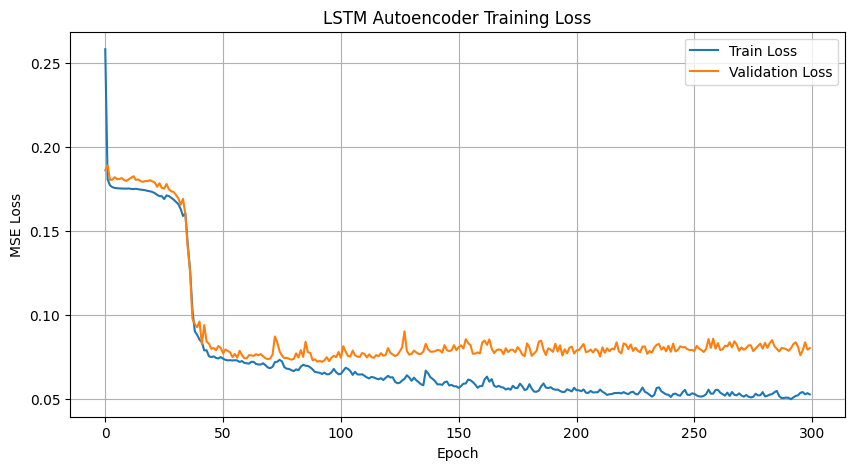

In [24]:
# =========================
# 17. PLOT TRAINING AND VALIDATION LOSS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# =========================
# 18. GET RECONSTRUCTIONS
# =========================

model.eval()

with torch.no_grad():
    X_train_reconstructed = model(X_train_torch.to(device)).cpu().numpy()
    X_val_reconstructed = model(X_val_torch.to(device)).cpu().numpy()
    X_test_reconstructed = model(X_test_torch.to(device)).cpu().numpy()

print("X_train_reconstructed shape:", X_train_reconstructed.shape)
print("X_val_reconstructed shape:", X_val_reconstructed.shape)
print("X_test_reconstructed shape:", X_test_reconstructed.shape)

X_train_reconstructed shape: (334, 25, 1)
X_val_reconstructed shape: (75, 25, 1)
X_test_reconstructed shape: (80, 25, 1)


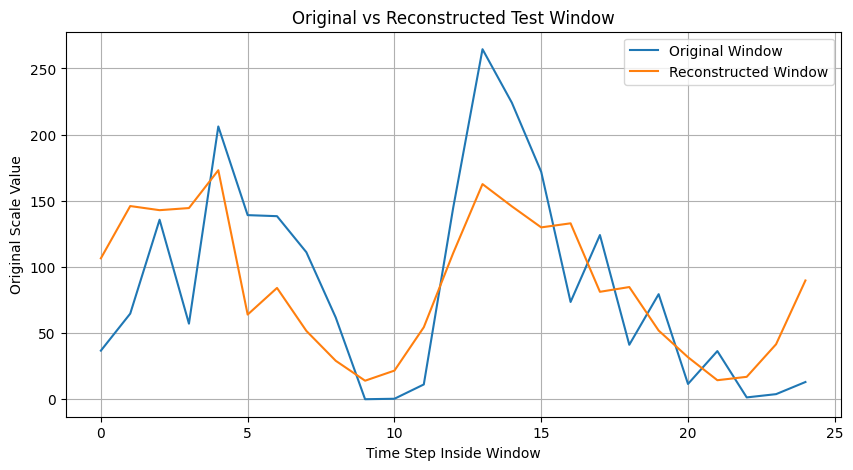

In [26]:
# =========================
# 19. PLOT ONE TEST WINDOW RECONSTRUCTION
# =========================

idx = 0

original_window_scaled = X_test[idx].reshape(-1, 1)
reconstructed_window_scaled = X_test_reconstructed[idx].reshape(-1, 1)

original_window = scaler.inverse_transform(original_window_scaled)
reconstructed_window = scaler.inverse_transform(reconstructed_window_scaled)

plt.figure(figsize=(10, 5))
plt.plot(original_window, label="Original Window")
plt.plot(reconstructed_window, label="Reconstructed Window")
plt.xlabel("Time Step Inside Window")
plt.ylabel("Original Scale Value")
plt.title("Original vs Reconstructed Test Window")
plt.legend()
plt.grid(True)
plt.show()

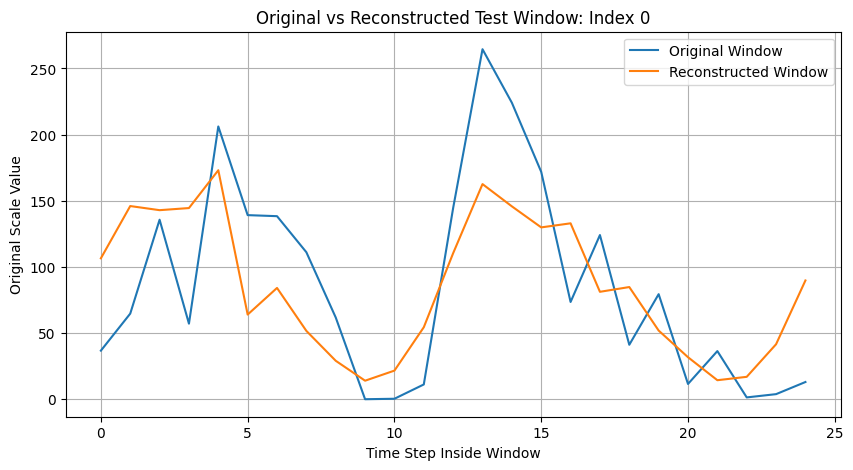

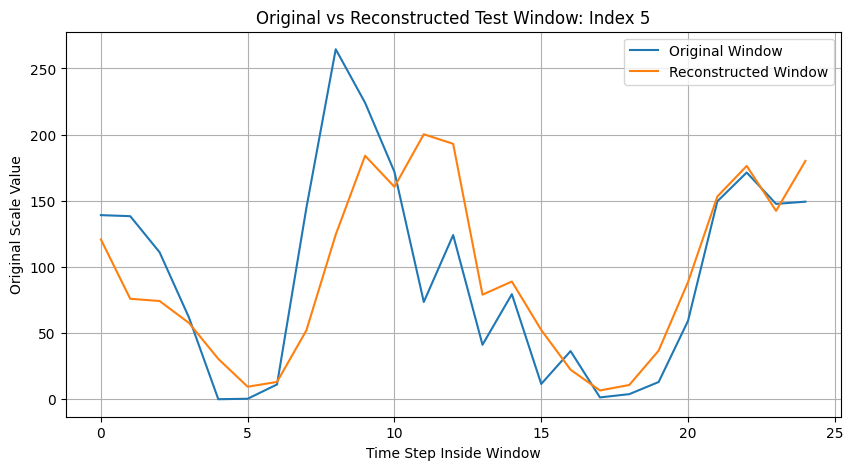

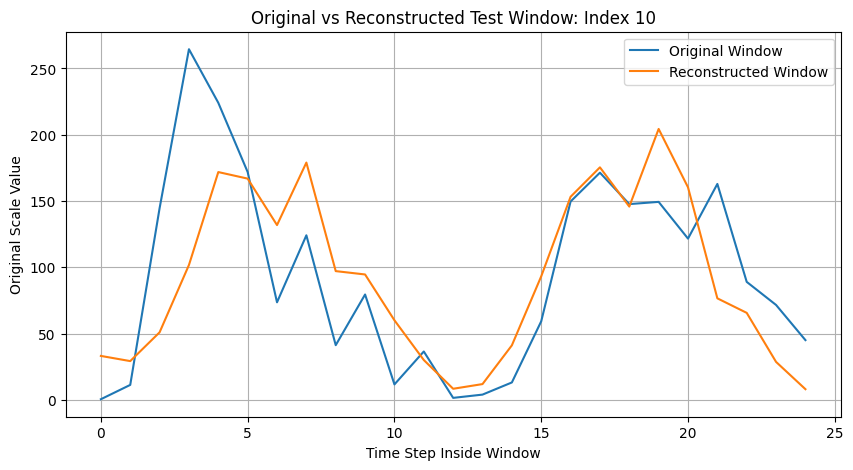

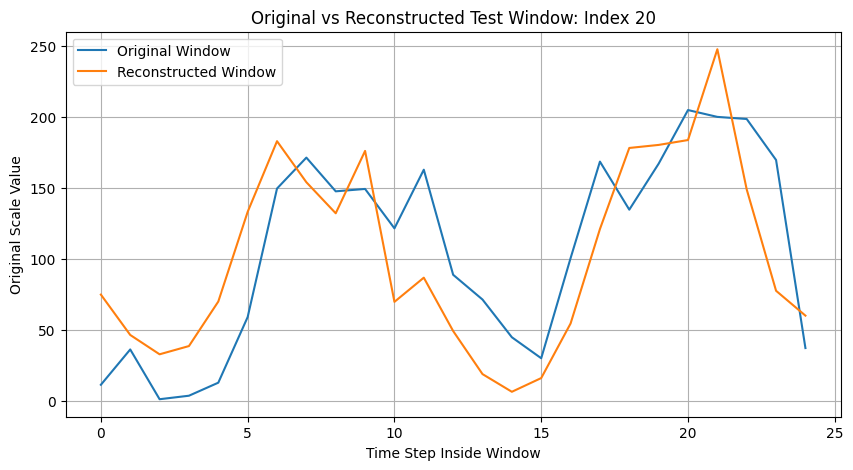

In [27]:
# =========================
# 20. PLOT MULTIPLE TEST WINDOW RECONSTRUCTIONS
# =========================

window_indices = [0, 5, 10, 20]

for idx in window_indices:
    if idx >= len(X_test):
        continue

    original_window_scaled = X_test[idx].reshape(-1, 1)
    reconstructed_window_scaled = X_test_reconstructed[idx].reshape(-1, 1)

    original_window = scaler.inverse_transform(original_window_scaled)
    reconstructed_window = scaler.inverse_transform(reconstructed_window_scaled)

    plt.figure(figsize=(10, 5))
    plt.plot(original_window, label="Original Window")
    plt.plot(reconstructed_window, label="Reconstructed Window")
    plt.xlabel("Time Step Inside Window")
    plt.ylabel("Original Scale Value")
    plt.title(f"Original vs Reconstructed Test Window: Index {idx}")
    plt.legend()
    plt.grid(True)
    plt.show()

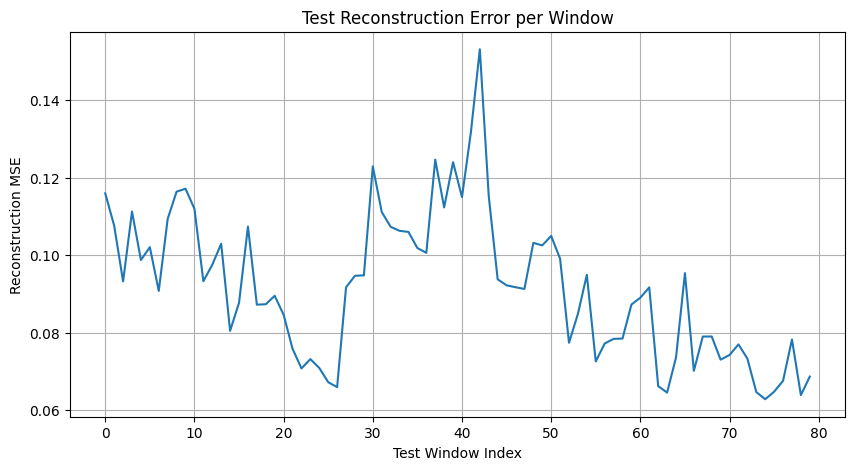

In [28]:
# =========================
# 21. RECONSTRUCTION ERROR PER TEST WINDOW
# =========================

test_errors = np.mean((X_test - X_test_reconstructed) ** 2, axis=(1, 2))

plt.figure(figsize=(10, 5))
plt.plot(test_errors)
plt.xlabel("Test Window Index")
plt.ylabel("Reconstruction MSE")
plt.title("Test Reconstruction Error per Window")
plt.grid(True)
plt.show()

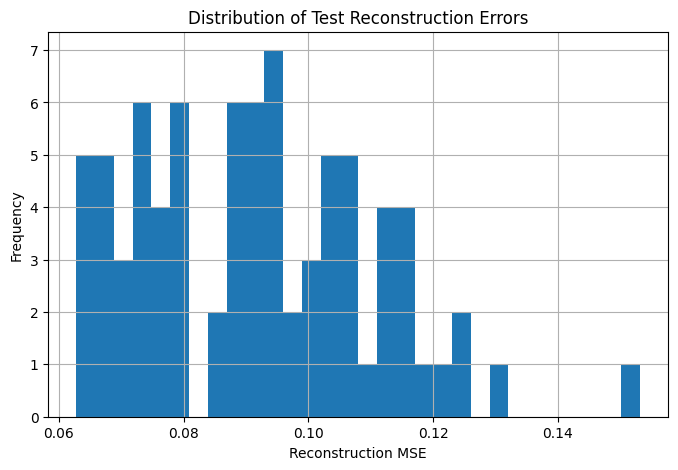

In [29]:
# =========================
# 22. HISTOGRAM OF TEST RECONSTRUCTION ERROR
# =========================

plt.figure(figsize=(8, 5))
plt.hist(test_errors, bins=30)
plt.xlabel("Reconstruction MSE")
plt.ylabel("Frequency")
plt.title("Distribution of Test Reconstruction Errors")
plt.grid(True)
plt.show()

In [30]:
# =========================
# 23. EXTRACT LATENT VECTORS OF SIZE 6
# =========================

model.eval()

with torch.no_grad():
    x_enc_repeated_train, enc_out_train = model.encoder(X_train_torch.to(device))
    x_enc_repeated_val, enc_out_val = model.encoder(X_val_torch.to(device))
    x_enc_repeated_test, enc_out_test = model.encoder(X_test_torch.to(device))

latent_train = x_enc_repeated_train[:, 0, :].cpu().numpy()
latent_val = x_enc_repeated_val[:, 0, :].cpu().numpy()
latent_test = x_enc_repeated_test[:, 0, :].cpu().numpy()

print("latent_train shape:", latent_train.shape)
print("latent_val shape:", latent_val.shape)
print("latent_test shape:", latent_test.shape)

latent_train shape: (334, 6)
latent_val shape: (75, 6)
latent_test shape: (80, 6)


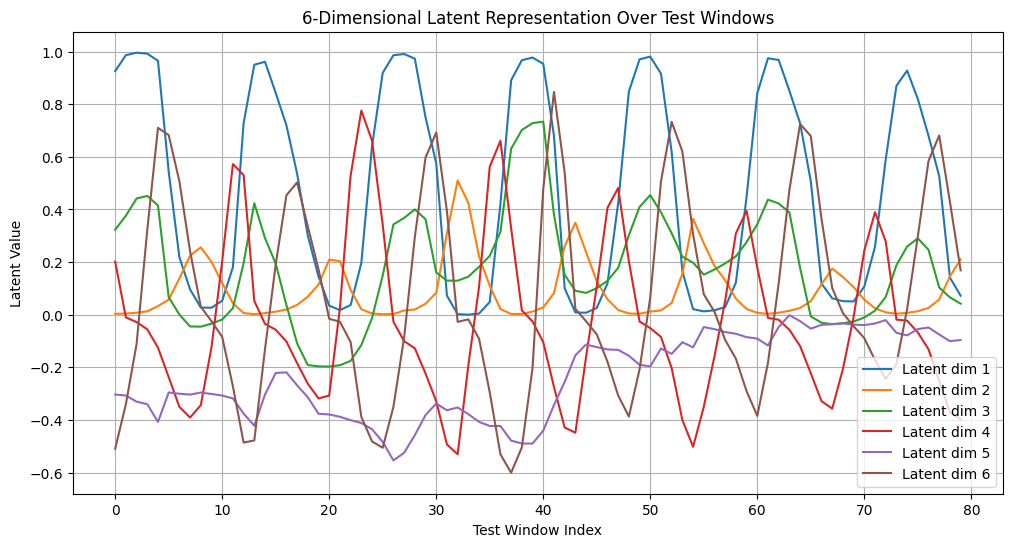

In [31]:
# =========================
# 24. PLOT LATENT FEATURES OVER TEST WINDOWS
# =========================

plt.figure(figsize=(12, 6))

for i in range(latent_test.shape[1]):
    plt.plot(latent_test[:, i], label=f"Latent dim {i + 1}")

plt.xlabel("Test Window Index")
plt.ylabel("Latent Value")
plt.title("6-Dimensional Latent Representation Over Test Windows")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# =========================
# 25. RECONSTRUCT A CONTINUOUS TEST SERIES FROM OVERLAPPING WINDOWS
# =========================

def reconstruct_series_from_windows(windows):
    """
    Converts overlapping reconstructed windows back into one continuous series
    by averaging overlapping predictions.
    
    windows shape: (num_windows, window_size, 1)
    """

    num_windows = windows.shape[0]
    window_size = windows.shape[1]

    reconstructed = np.zeros(num_windows + window_size)
    counts = np.zeros(num_windows + window_size)

    for i in range(num_windows):
        reconstructed[i:i + window_size] += windows[i, :, 0]
        counts[i:i + window_size] += 1

    reconstructed = reconstructed / counts

    return reconstructed.reshape(-1, 1)


test_reconstructed_scaled_series = reconstruct_series_from_windows(X_test_reconstructed)
test_original_scaled_series = reconstruct_series_from_windows(X_test)

test_reconstructed_series = scaler.inverse_transform(test_reconstructed_scaled_series)
test_original_series = scaler.inverse_transform(test_original_scaled_series)

print("test_original_series shape:", test_original_series.shape)
print("test_reconstructed_series shape:", test_reconstructed_series.shape)

test_original_series shape: (105, 1)
test_reconstructed_series shape: (105, 1)


/var/folders/lb/7b4tdngx1x1g1zn730j5fv900000gq/T/ipykernel_79778/1483512033.py:23: RuntimeWarning: invalid value encountered in divide
  reconstructed = reconstructed / counts


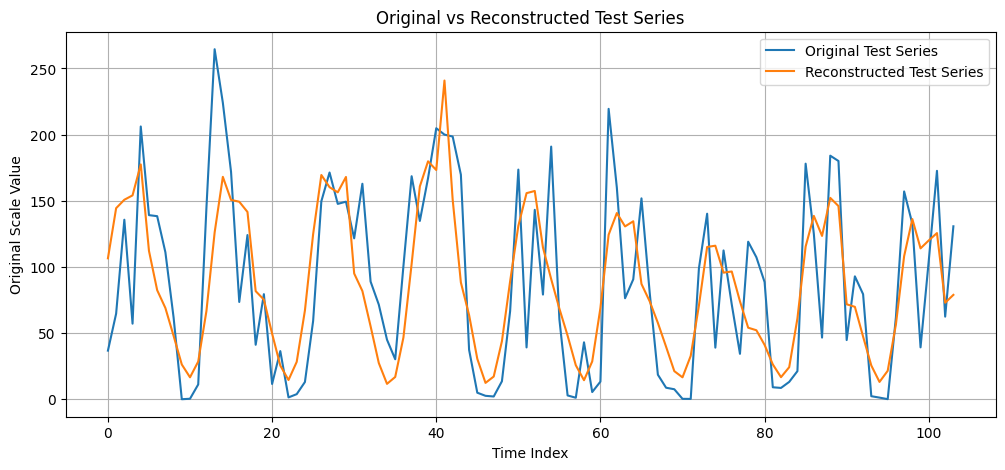

In [33]:
# =========================
# 26. PLOT CONTINUOUS ORIGINAL VS RECONSTRUCTED TEST SERIES
# =========================

plt.figure(figsize=(12, 5))
plt.plot(test_original_series, label="Original Test Series")
plt.plot(test_reconstructed_series, label="Reconstructed Test Series")
plt.xlabel("Time Index")
plt.ylabel("Original Scale Value")
plt.title("Original vs Reconstructed Test Series")
plt.legend()
plt.grid(True)
plt.show()